In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().mean()

,0
Survived,0.000000
Age,0.198653
Fare,0.000000


In [8]:
X=df.drop(columns=['Survived'])
y=df['Survived']

## train-test-split

In [9]:
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.2,random_state =42)

In [10]:
X_train.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


In [12]:
X_train['Age_imputed']= X_train["Age"]
X_test['Age_imputed']= X_test["Age"]

As of now, Age_imputed == age

In [13]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


# the number of sample values generated should be equal to the number of missing values in the age column


In [20]:
null_indices_train = X_train[X_train['Age_imputed'].isnull()].index
num_null_train = len(null_indices_train)
sampled_values_train = X_train["Age"].dropna().sample(num_null_train, random_state=42).values
X_train.loc[null_indices_train, 'Age_imputed'] = sampled_values_train


#now applying the same techniqiue on test data as well
null_indices_test = X_test[X_test['Age_imputed'].isnull()].index
num_null_test = len(null_indices_test)
sampled_values_test = X_test["Age"].dropna().sample(num_null_test, random_state=42).values
X_test.loc[null_indices_test, 'Age_imputed'] = sampled_values_test

In [23]:
X_train['Age_imputed'].isnull().sum()

np.int64(0)

#Now `Age_imputed` has no missing value

In [24]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,30.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


#Distribution of `Age` and `Age_imputed` is same

/tmp/ipykernel_1478/2375819013.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label="original")
/tmp/ipykernel_1478/2375819013.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"],label="imputed")


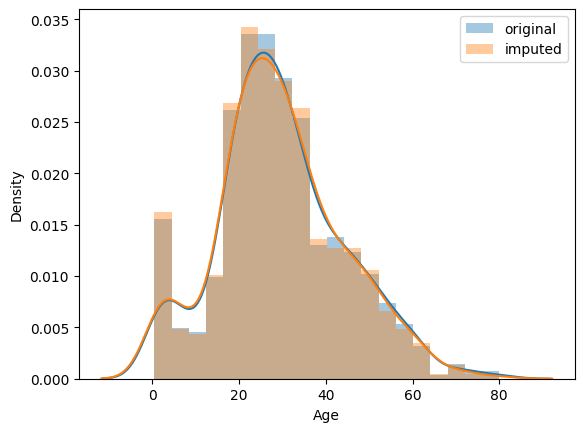

In [27]:
sns.distplot(X_train['Age_imputed'],label="original")
sns.distplot(X_train["Age"],label="imputed")
plt.legend()
plt.show()

# variance is almost same

In [28]:
print('original variable variance:',X_train['Age'].var())
print('imputed variable variance:',X_train['Age_imputed'].var())

original variable variance: 210.2517072477438
imputed variable variance: 214.623005221124


# Now Comparing Covariance

In [32]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,62.352115
Age,71.580633,210.251707,210.251707
Age_imputed,62.352115,210.251707,214.623005


## Outliers doesnt change

<Axes: >

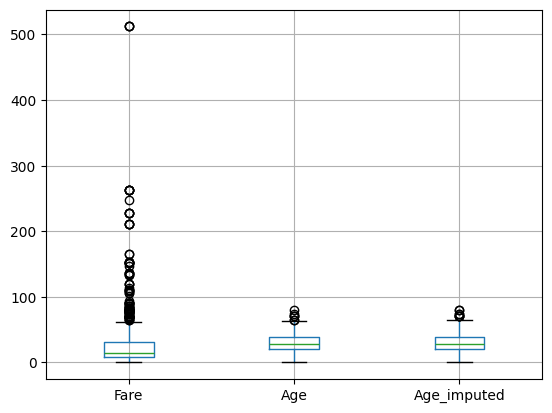

In [33]:
X_train[['Fare','Age','Age_imputed']].boxplot()

# the model should alwys generate same output
like: we give fare as input and ask to predict the age then everytime,
the age should be the same.

In [37]:
# Define a sample observation for demonstration purposes
observation = {'Fare': 50}

sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))
print(f"Sampled Age for observation with Fare {observation['Fare']}: {sampled_value.iloc[0]}")

Sampled Age for observation with Fare 50: 32.0


In [40]:
data= pd.read_csv("/content/train (1).csv",usecols=['GarageQual','FireplaceQu','SalePrice'])

In [41]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [42]:
data.isnull().mean() * 100


,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [54]:

X = data # we have taken whole columns from our dataset
y = data['SalePrice']


#train-test-split

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [59]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [60]:
X_train.sample(5)


,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
594,NaN,TA,110000,TA,NaN
1137,NaN,NaN,94000,NaN,NaN
473,Ex,TA,440000,TA,Ex
814,NaN,TA,116000,TA,NaN
1171,TA,TA,163000,TA,TA


In [61]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_1478/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp

In [62]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)
temp.columns = ['original', 'imputed']

In [49]:
temp


,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.038527
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


# Comparison before versus after `FireplaceQu`

In [63]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)


temp

,count,count
TA,0.951043,0.951199
Fa,0.037171,0.035959
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


## Before:

/tmp/ipykernel_1478/1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_1478/1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu

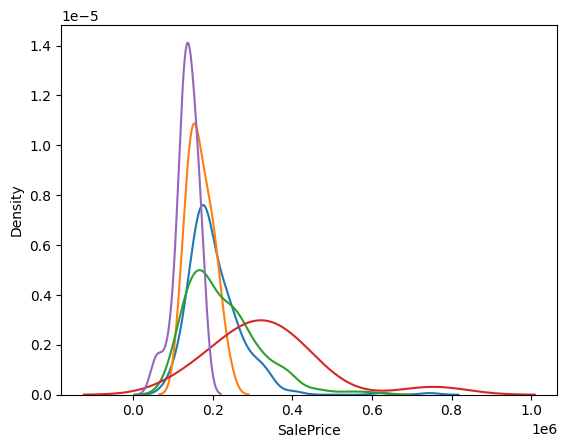

In [51]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

## After:

/tmp/ipykernel_1478/3976625375.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_1478/3976625375.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Fir

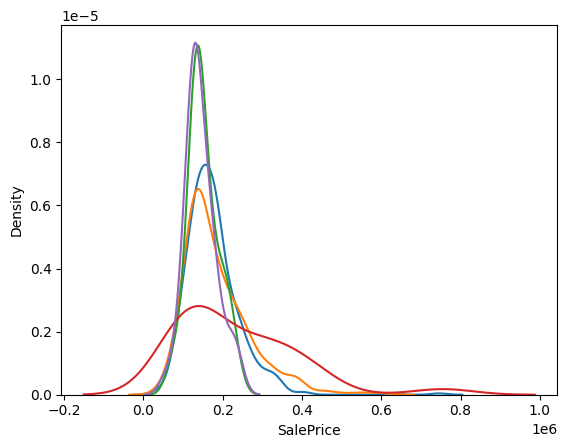

In [52]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()
